In [1]:
%load_ext autoreload
%autoreload 2

from copy import deepcopy

import numpy as np
from matplotlib import pyplot as plt

import ipywidgets as widgets
from ipywidgets import interact, interact_manual

import pandas as pd
import seaborn as sns

from paper_utils import wandb_restore
from paper utils import *

i2c = {i: f"\x1b[{a}" for i, a in enumerate([
    '1m', '31m', '33m', '34m', '35m', '36m', '37m', '38m'])}
r = "\x1b[0m"

* n_regenrate 1--5 is currently running at https://wandb.ai/jlko/hallu_long/table?workspace=user-jlko (to give us the ablation we want!)

In [438]:
# Initial runs.
runs = {
    # note this has the question extraction bug (no numbering), so results are likely a bit pessimistic
    # (also has the major/minor replacement bug)
    'flexible': 'hallu_long/5yfel47n',
    # get a yes/no per regenerated question!
    'flexible_with_prob': 'hallu_long/n4vgl562',
    'entailment': 'hallu_long/gjkhe90u',
    # is with not_answerable and improved question generation prompt
    'entailment_v2': 'hallu_long/buo2yw8e',
    'deberta': 'hallu_long/3xyx3v89', 
    # deberta run where expected answer not used for clustering (comparison would be fairer if we had a new regen_answer)
    'deberta_no_expected': 'hallu_long/q8glz91c',
    # manually set uncertainty to maximum if 'not answerable', 'not provided', 'unclear', 'unknown' appears >= 2 times
    'deberta_not_answerable': 'hallu_long/dd13rmis',
    # is with not_answerable and improved question generation prompt
    'deberta_na_v2': 'hallu_long/d97uybct',
    'entailment_llm': 'hallu_long/eqlu6ldt',
    # ask for semantically equivalent instead of 'mean the same'
    'equivalent_llm': 'hallu_long/9egqfjs1',
    # ask closer to how we actually compute entailment: at least one entails the other!
    # (could even refine to include that they don't contradict each other?)
    '1way_entailment_llm': 'hallu_long/74yhw70v',
    'self_check': 'hallu_long/h0hl8glr',
    'ptrue': 'hallu_long/bgdgnaeq',
}

# 10/10/23 Final runs. Rerun across old questions and additional new questions.
runs = {
    **runs,
    'Fself_check': 'hallu_long/2madgs36',
    'Fptrue': 'hallu_long/runs/0j1oswba',
    # 'FptrueOrig': 'hallu_long/runs/6r8vh6on',  # prompt closer to original
    # monte carlo estimate of true probability
    'FptrueOrig': 'hallu_long/15igl3zh',
    # this one failed on the last datapoint, restore and recompute
    # 'FQADebertaEntailment': 'hallu_long/3twf6uqm',
    'FQADebertaEntailment': 'hallu_long/3vvlav6n',
    # update 2023/12/01: add strict entailment, see how that performs
    'FQADebertaEntailment-strict': 'hallu_long/5wcf35w7',
    'FQAFlexibleEquivalence': 'hallu_long/p44zr574',
    # 'FQADebertaEntailment-A1': 'hallu_long/hz1tngeb',  # x regenerated answers!
    # 'FQADebertaEntailment-A2': 'hallu_long/0vvn2qpx',  # x regenerated answers!
    # 'FQADebertaEntailment-A4': 'hallu_long/ttclhrxb',  # x regenerated answers!
    # 'FQADebertaEntailment-A5': 'hallu_long/xxwbx8k5',  # x regenerated answers!
    # 'FQADebertaEntailment-A6': 'hallu_long/vhiovr2r',  # 6 regenerated answers!

    # rerun with max_entropy for 'unknown' fixed (was not dependent on number of answers!!)
    'FQADebertaEntailment-A1': 'hallu_long/3eplwjch',
    'FQADebertaEntailment-A2': 'hallu_long/nidv2yi3',
    'FQADebertaEntailment-A4': 'hallu_long/71vq6uqb',
    'FQADebertaEntailment-A5': 'hallu_long/5izncbza',
    'FQADebertaEntailment-A6': 'hallu_long/zcs7qufa',
}


# all_results, all_metrics = {}, {}
for name, url in runs.items():
    if name not in all_results:
        print(i2c[0] + name + r)

        results, config = wandb_restore(url, 'results.pkl')
        print(config)
        print(results['results']['restored_config'])
    
        all_results[name] = results
        all_metrics[name] = results['results']['metrics']

FptrueOrig
{'wait': False, 'debug': False, 'model': 'PTrueOriginalBaseline', 'num_data': 1e+19, 'n_questions': 'three', 'n_regenerate': 3, 'truth_target': 'facts', 'yarin_and_seb': False, 'restore_stages': ['gen_qs', 'answer_qs'], 'entailment_type': 'lax', 'intermediate_export': True, 'restore_from_wandb_id': 'hallu_long/6r8vh6on', 'accept_restore_failure': False, 'n_stochastic_questions': 2}
{'wait': False, 'debug': False, 'model': 'PTrueOriginalBaseline', 'num_data': 1e+19, 'n_questions': 'three', 'n_regenerate': 3, 'truth_target': 'facts', 'yarin_and_seb': False, 'restore_stages': ['gen_qs', 'answer_qs'], 'intermediate_export': True, 'restore_from_wandb_id': 'hallu_long/0j1oswba', 'accept_restore_failure': False, 'n_stochastic_questions': 2}


In [439]:
wrongness = ['major_only', 'minor_and_major']

def get_vals(x):
    return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def plot_bar(entry, ax, i, color=None):
    m, l, h = get_vals(entry)
    ax.bar(i, m, color=color)
    ax.plot(2*[i], [l, h], c='grey')

def qidx2fidx(qidx, fidxinq, results):

    n_facts = 0
    # Go through individual questions.
    for question in results['results']['questions']:
        # If we have reached the index of the question then break.
        if int(question.split('-')[1]) == qidx:
            n_facts += fidxinq
            break
        n_facts += len(results['results']['questions'][question]['facts'])

    return n_facts

# Make sure total number of facts matches between approaches!
# Does not work if we include different number of datapoints between runs!
# for run in runs:
    # assert qidx2fidx(0, 0, all_results[run]) == 0
    # assert qidx2fidx(0, 1, all_results[run]) == 1
    # assert qidx2fidx(1, 0, all_results[run]) == 7
    # assert qidx2fidx(1, 1, all_results[run]) == 8
    # assert qidx2fidx(100, 0, all_results[run]) == len(all_metrics[run]['uncertainties'])
    # only holds when all runs are finished
    # assert qidx2fidx(100, 0, all_results[run]) == sum([len(d[-1]) for d in dataset])

In [4]:
@interact
def q(name=all_results.keys()):
    results = all_results[name]
    
    for name, prompt in results['results']['prompts'].items():
        print(f'{i2c[0]}{name+":":<10}{r}\n{prompt}\n')

interactive(children=(Dropdown(description='name', options=('flexible', 'flexible_with_prob', 'entailment', 'e…

In [5]:
@interact
def q(name=all_results.keys(), idx=list(results['results']['questions'].keys()), wrong=wrongness[::-1], fact_idx=range(20)):

    results = all_results[name]
    metrics = all_metrics[name]

    rqd = results['results']['questions'][idx]

    print(f'{i2c[0]}Question{r}: {rqd["user_question"]}\n')
    print(f'{i2c[0]}Initial Reply{r}: {rqd["init_reply"]}\n')
    print(f'{i2c[0]}{"Idx":<3} {"Truth":<5} {"Uncer":<5} Fact {r}')

    didx = int(idx.split('-')[1])    
    labels = metrics[wrong]['per_question']['labels']
    for fidx, fact in enumerate(results['results']['questions'][idx]['facts']):

        global_fidx = qidx2fidx(didx, fidx, results)
        uncertainty = metrics['uncertainties'][global_fidx]
        label = labels[global_fidx]
        label = f'{i2c[5]}{"True":<5}{r}' if label else f'{i2c[1]}{"False":<5}{r}'
        print(f'{fidx:<3} {i2c[1]}{str(label):<5}{r} {i2c[3]}{uncertainty:.3f}{r} {fact}')

        # does not work for p_true --> need to implement something later
    try:
        print('\n')
        print(80*'-')
        print(f'{i2c[0]}Selected fact_idx{r}: {i2c[0]}{fact_idx}{r} ')
        fact = results['results']['questions'][idx]['facts'][fact_idx]
        print(f'{i2c[0]}Selected fact{r}: {fact}')
        uncertainty = np.mean([k['uncertainty'] for k in rqd['propositions'][f'prop-{fact_idx}'].values()])
        print(f'{i2c[0]}Fact uncertainty{r}: {uncertainty:.3f}\n')

        for q, regen_dict in rqd['propositions'][f'prop-{fact_idx}'].items():
    
            print(f'{i2c[0]}{q}{r}: {regen_dict["question"]}')
            if 'expected_answer' in regen_dict:
                print(f'\t{i2c[0]}Expected Answer{r}: {regen_dict["expected_answer"]}')
    
            print(f'\t{i2c[0]}Answers{r}: {regen_dict["answers"]}')
            equiv = regen_dict["equiv_response"]
            try:
                equiv = f'{i2c[5]}{equiv}{r}' if 'yes' in equiv.lower() else f'{i2c[1]}{equiv:<5}{r}'
            except:
                pass
            print(f'\t{i2c[0]}Equivalent{r}: {equiv}')
            unc = regen_dict["uncertainty"]
            unc = f'{i2c[1]}{unc}{r}' if unc else f'{i2c[5]}{unc:<5}{r}'
            print(f'\t{i2c[0]}Uncertainty{r}: {unc}')
    except:
        pass
        

interactive(children=(Dropdown(description='name', options=('flexible', 'flexible_with_prob', 'entailment', 'e…

# Metrics

In [440]:
truths_values = np.concatenate([d[-1] for d in data[3:]])
len(data[3:]), truths_values.shape, np.sum(truths_values != 'True')

(21, (150,), 45)

In [441]:
allms = deepcopy(all_metrics)
data = []
for run in allms:
    for wrong in wrongness:

        # add overall uncertainty for full picture
        allms[run][wrong]['uncertainty']['accuracy_at_1_answer_fraction'] = allms[run][wrong]['performance']

        for metric in allms[run][wrong]['uncertainty']:
            m, l, h = get_vals(allms[run][wrong]['uncertainty'][metric])
            for name, value in zip(['mean', 'low', 'high'], [m, l, h]):
                data.append([run, wrong, metric, name, value])
                
df = pd.DataFrame(data, columns=['run', 'wrong', 'metric', 'name', 'value'])



In [442]:
def barplots(exclude=[], include=[], wrongness=['minor_and_major']):

    df2 = deepcopy(df)
    df2 = df2[df2.metric != 'mean_uncertainty']
    if exclude:
        df2 = df2[df2.run.map(lambda x: x not in exclude)]
    if include:
        df2 = df2[df2.run.map(lambda x: x in include)]
    
    for name, gdf in df2.groupby('wrong'):
        if name in wrongness:
            fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)
            ax.set_title(name)
            # gdf = gdf.sort_values(['run', 'metric'])
            g = sns.barplot(
                x="metric",       # x variable name
                y="value",       # y variable name
                hue="run",  # group variable name
                data=gdf.set_index('name').loc['mean'],     # dataframe to plot
                ax=ax,
            )
        
            # https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
            x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
            y_coords = [p.get_height() for p in ax.patches]
        
            for kind in ['low', 'high']:
                tmp = gdf.set_index('name').loc[kind]
                tmp = tmp.value.values
                ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
                ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
            ax.grid(zorder=-100, alpha=0.2)
            ax.set_ylim(0.3, 1)
        plt.tight_layout()

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

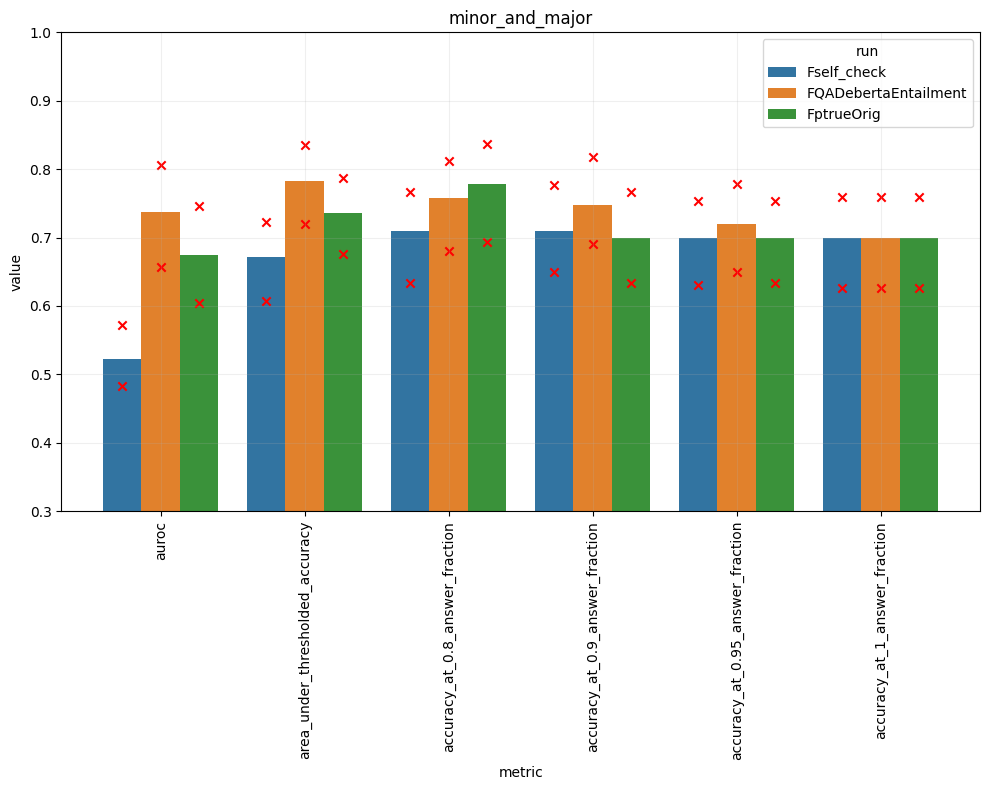

In [443]:
# final experiments
barplots(include=['Fself_check', 'FptrueOrig', 'FQADebertaEntailment'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

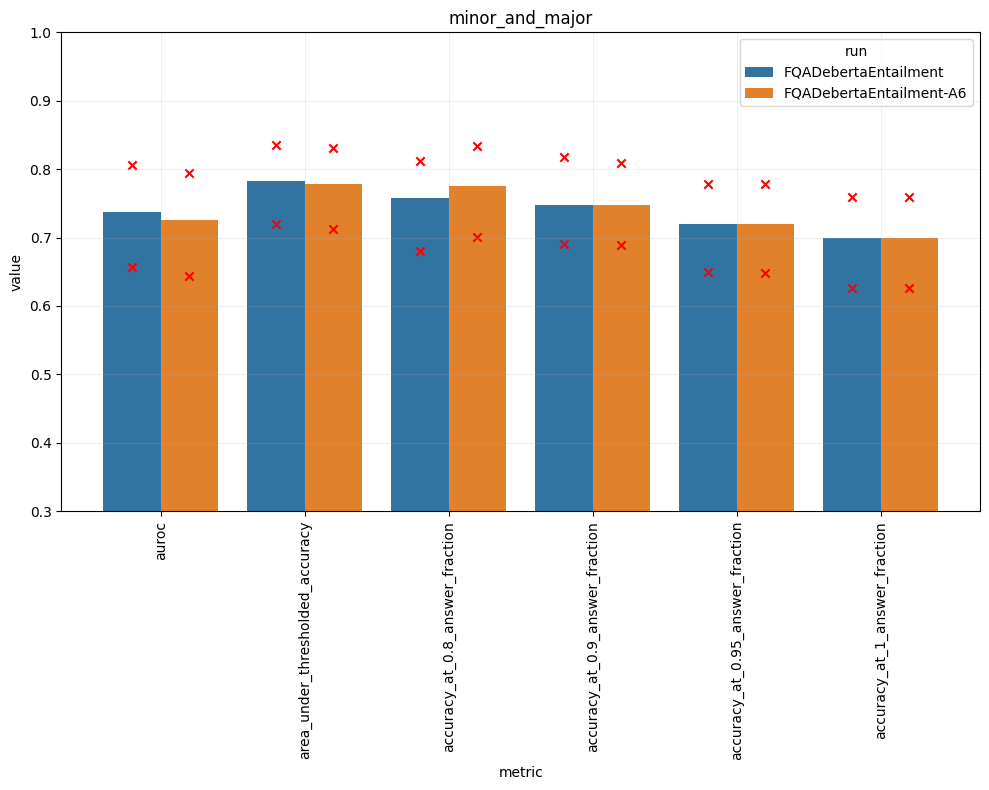

In [30]:
# ablation of different nubmer of regenerated answers
barplots(include=['FQADebertaEntailment', 'FQADebertaEntailment-A6'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

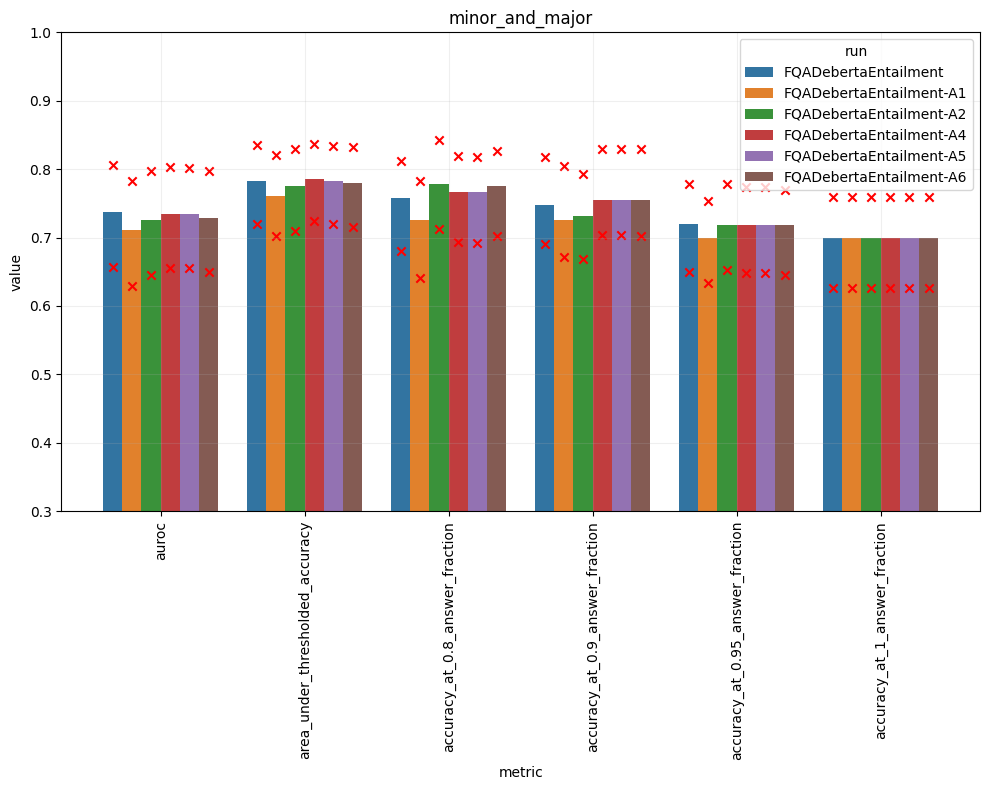

In [389]:
# UPDATE 25/11: filled in the gaps
# FQADebertaEntailment ist the default one with three regenerations per question!
barplots(include=['FQADebertaEntailment', 'FQADebertaEntailment-A6', 'FQADebertaEntailment-A5', 'FQADebertaEntailment-A4', 'FQADebertaEntailment-A2', 'FQADebertaEntailment-A1'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

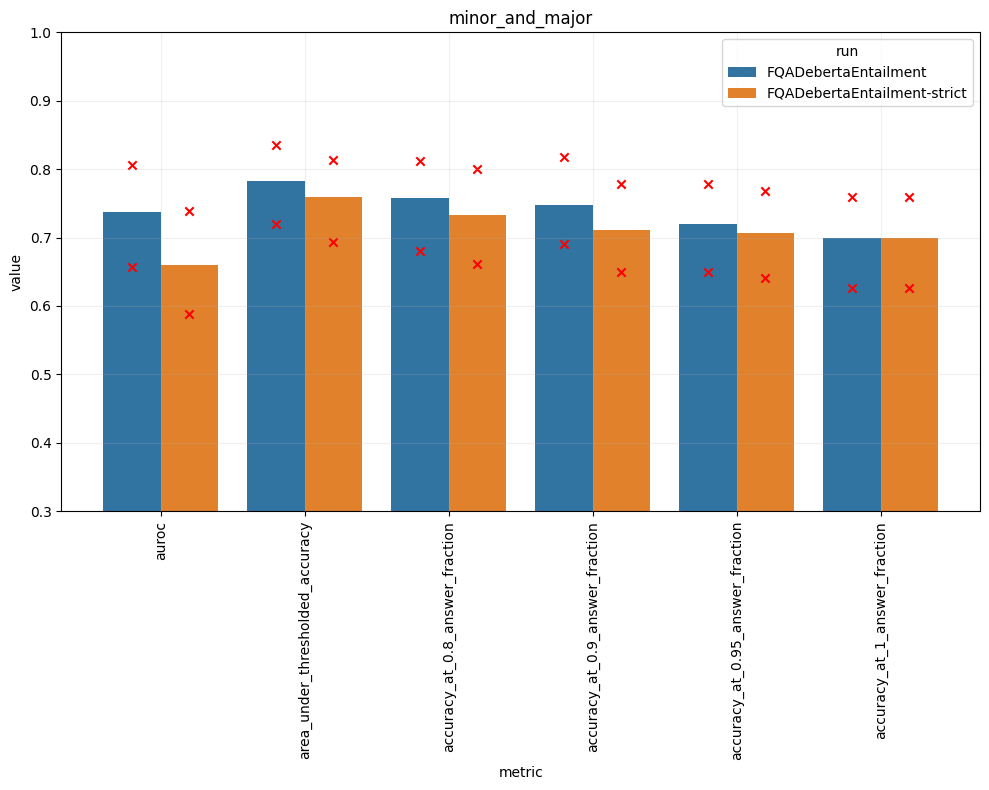

In [397]:
# update 2023/12/01: strict vs lax entailment for deberta
barplots(include=['FQADebertaEntailment', 'FQADebertaEntailment-strict'])

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

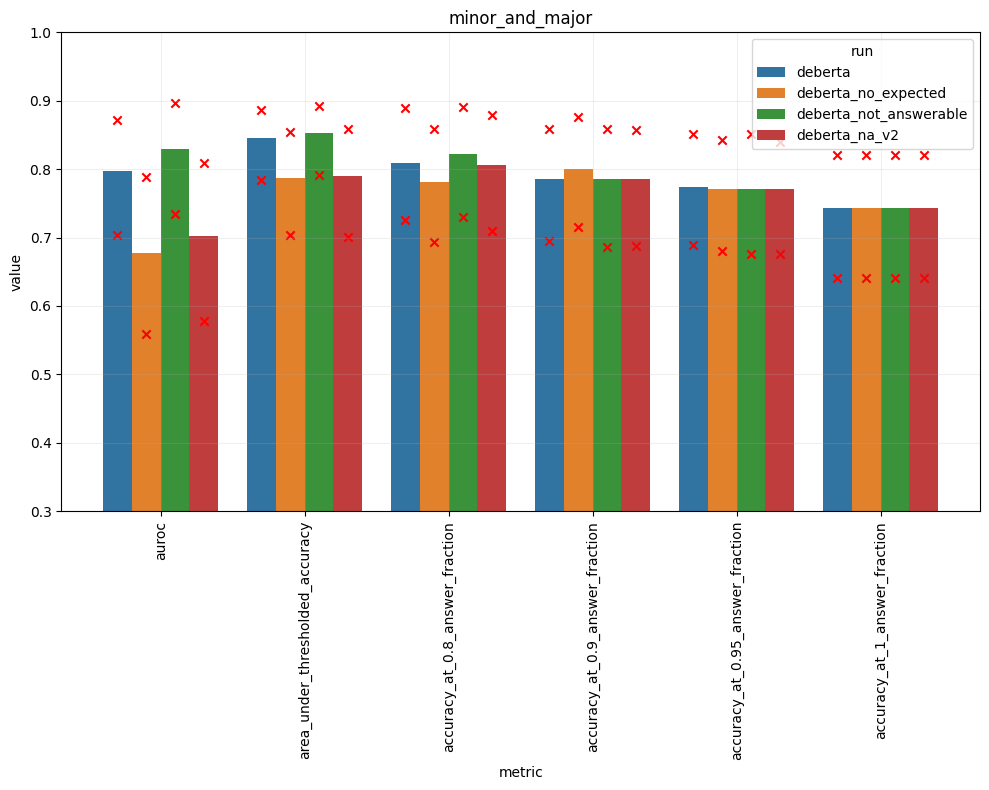

In [33]:
# some other deberta variants from preliminary investigation (dataset half the size)

# deberta_no_expected: deberta run where expected answer not used for clustering (comparison would be fairer if we had a new regen_answer)
# deberta_not_answerable: manually set uncertainty to maximum if 'not answerable', 'not provided', 'unclear', 'unknown' appears >= 2 times
# deberta_na_v2: is with not_answerable and improved question generation prompt

# NOTE: we end up using deberta_not_answerable!!
# NOTE: we are always using non-strict entailment here!!

barplots(
    include=['deberta', 'deberta_no_expected', 'deberta_not_answerable', 'deberta_na_v2']
)

/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_1259822/2790621460.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


<Figure size 640x480 with 0 Axes>

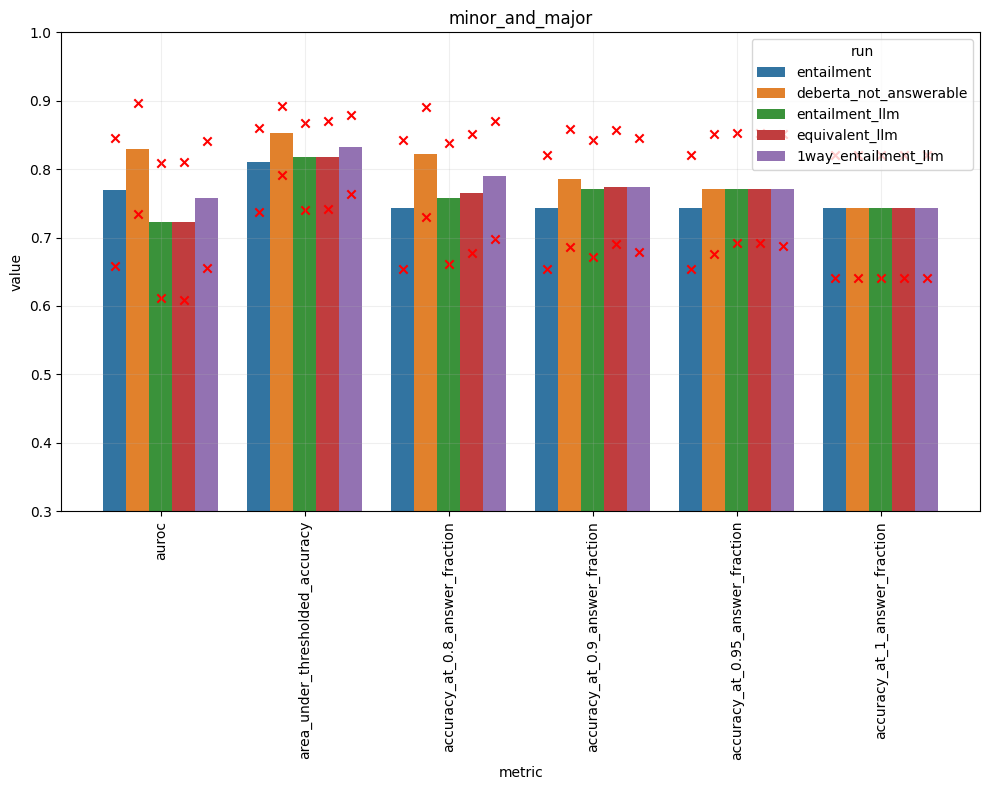

In [36]:
# some other variants from preliminary investigation (dataset half the size)


# LLM equivalence + clustering

# entailment: directly ask LLM if the generated answers are equivalent (all questions at the same time)
# entailment_llm: check entailment with gpt-4
# equivalent_llm: check if answers are 'equivalent' with gpt-4 (simple change of phrasing)
# 1way_entailment_llm: ask closer to how we actually compute (non-strict) entailment: at least one entails the other!

barplots(
    include=['entailment', 'entailment_llm', 'equivalent_llm', '1way_entailment_llm', 'deberta_not_answerable']
)

In [114]:
include=['deberta', 'deberta_no_expected', 'deberta_not_answerable', 'deberta_na_v2', 'entailment', 'entailment_llm', 'equivalent_llm', '1way_entailment_llm']

df.set_index('wrong').loc['minor_and_major'].set_index('metric').loc['auroc'].set_index('run').loc[include].reset_index().pivot(index='run', columns='name', values='value')

name,high,low,mean
run,,,
1way_entailment_llm,0.841392,0.655256,0.757759
deberta,0.871447,0.703461,0.797414
deberta_na_v2,0.808524,0.578698,0.702586
deberta_no_expected,0.789059,0.559772,0.677155
deberta_not_answerable,0.896982,0.734510,0.829741
entailment,0.845779,0.658244,0.769397
entailment_llm,0.809430,0.611673,0.722845
equivalent_llm,0.810290,0.608875,0.722845


# Average length of generation

In [126]:
import os
os.chdir('/users/jansen/long_hallu')

In [404]:
from data import data 

In [415]:
for d in data: break

In [416]:
# average over (total facts per question)
n_gen = [len(' '.join(d[-2])) for d in data]
from scipy.stats import sem 

stats = lambda x: {'mean': np.mean(x), 'sem': sem(x), 'std': np.std(x), 'median': np.median(x)}
stats(n_gen)

{'mean': 445.5,
 'sem': 25.079439006276942,
 'std': 120.27676417330157,
 'median': 423.0}

In [417]:
# average over (full answer per question)
n_gen = [len(d[2]) for d in data]
from scipy.stats import sem 

stats = lambda x: {'mean': np.mean(x), 'sem': sem(x), 'std': np.std(x), 'median': np.median(x)}
stats(n_gen)

{'mean': 441.9583333333333,
 'sem': 25.387680965514818,
 'std': 121.75504067822226,
 'median': 432.0}

# Plot Cluster Distribution

stats: {'mean': 1.742338251986379, 'sem': 0.02993024048054981, 'std': 0.8878744166810514, 'median': 2.0}
stats: {'mean': 0.25, 'sem': 0.1000716036185053, 'std': 0.17332910186214467, 'median': 0.22190692395005673}
1.0


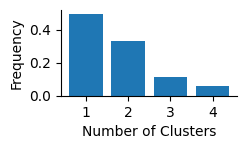

In [399]:
def plot_cluster_dist(run, save_path=None):
    clusters = []
    for datum, d_dict in all_results[run]['results']['questions'].items():
        for proposition, p_dict in d_dict['propositions'].items():
            for question, q_dict in p_dict.items():
                cluster = q_dict['equiv_response']
                if 'not answerable' not in cluster:
                    clusters.append(cluster)
    
    
    # plot distribution of number of unique clusters
    cluster_counts = [len(np.unique(cluster)) for cluster in clusters]
    print('stats:', stats(cluster_counts))
    uniq_counts, count_values = np.unique(cluster_counts, return_counts=True)
    fig, ax = plt.subplots(figsize=(TEXTWIDTH / 2, TEXTWIDTH / 2 / GOLDEN_RATIO))
    total = sum(count_values)
    cluster_frequencies = [count / total for count in count_values]
    print('stats:', stats(cluster_frequencies))
    print(sum(cluster_frequencies))
    ax.bar(uniq_counts, cluster_frequencies)
    # ax.set_title(run)
    ax.set_xticks(uniq_counts)
    ax.set_xlabel('Number of Clusters')
    ax.set_ylabel('Frequency')
    sns.despine()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    
    

plot_cluster_dist('FQADebertaEntailment', save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_paragraph_n_clusters_default.pdf")

note that this is for 3 regenerated answers (i.e. 4 answers total)

stats: {'mean': 2.080681818181818, 'sem': 0.04698027268932515, 'std': 1.3928680315470614, 'median': 2.0}
stats: {'mean': 0.14285714285714285, 'sem': 0.06258687109410567, 'std': 0.15330589877790485, 'median': 0.05227272727272727}
1.0


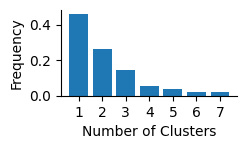

In [400]:
plot_cluster_dist('FQADebertaEntailment-A6', save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_paragraph_n_clusters_6_generations.pdf")

In [444]:
COLORS = {
    "semantic_entropy_sum-normalized-rao": '#0173b2',
    "FQADebertaEntailment": '#56b4e9',
    "FQADebertaEntailment-A1": '#67d8ff',
    "FQADebertaEntailment-A2": '#5ec6ff',
    "FQADebertaEntailment-A4": '#4da2d1',
    "FQADebertaEntailment-A5": '#4490ba',
    "FQADebertaEntailment-A6": '#3c7da3',
    "cluster_assignment_entropy": '#56b4e9',
    "regular_entropy": "#89CFF0",
    "p_ik": '#ece133',
    "p_false": '#d55e00',
    "FptrueOrig": '#d55e00',
    "ER - BioASQ" : "#ece133",
    "ER - TriviaQA": "#ece133",
    "ER - SQuAD" : "#ece133",
    "Fself_check": "#fbafe4",
    'deberta_not_answerable': sns.color_palette("hls", 5)[0],
    'entailment': sns.color_palette("hls", 5)[1],
    'entailment_llm': sns.color_palette("hls", 5)[2],
    'equivalent_llm': sns.color_palette("hls", 5)[3],
    '1way_entailment_llm': sns.color_palette("hls", 5)[4]
}

CROSSHATCH = {
    "Semantic Entropy": '',
    "Naive Entropy": '',
    "Embedding Regression": '',
    "p(True) - Kadavath et al.": '',
    "clarify_when_appropriate": '',
    "detect_ambiguity": '',
    "ER - BioASQ" : "///",
    "ER - TriviaQA": "---",
    "ER - SQuAD" : "\\\\\\",
}

MODEL_MAPPING = {
    'falcon-7b': 'Falcon-7B',
    'falcon-40b': 'Falcon-40B',
    'falcon-40b-instruct': 'Falcon-40B Instruct',
    'llama-7b': 'LLaMA-7B',
    'llama-13b': 'LLaMA-13B',
    'llama-65b': 'LLaMA-65B',
}

PRETTY_NAMES = {
    "bioasq": "BioASQ",
    "trivia_qa": "TriviaQA",
    "squad": "SQuAD",
    "cluster_assignment_entropy": "Discrete Semantic Entropy",
    "regular_entropy": "Naive Entropy",
    "semantic_entropy_sum-normalized-rao": "Semantic Entropy",
    "p_ik": "Embedding Regression",
    "p_false": "p(True) - Kadavath et al.",
    "Fself_check": "Self-check Baseline",
    "FptrueOrig": "P(True) - Kadavath et al. variant",
    "FQADebertaEntailment": "Discrete Semantic Entropy",
}

METRIC_NAMES = {
    "auroc": "AUROC",
    "accuracy_at_0.8_answer_fraction": "80%",
    "accuracy_at_0.9_answer_fraction": "90%",
    "accuracy_at_0.95_answer_fraction": "95%",
    "accuracy_at_1_answer_fraction": "100%",
    "area_under_thresholded_accuracy": "AU Rejection\nAccuracy\nCurve",
}

TEXTWIDTH = 5.14838
GOLDEN_RATIO = 1.618

In [453]:
def restyled_barplots(exclude=[], include=[], wrongness=['minor_and_major'], save_path=None, custom_names=None, ncols=2, y_lims=(0.4,0.85)):

    df2 = deepcopy(df)
    df2 = df2[df2.metric != 'mean_uncertainty']
    if exclude:
        df2 = df2[df2.run.map(lambda x: x not in exclude)]
    if include:
        df2 = df2[df2.run.map(lambda x: x in include)]

    for original_name, new_name in METRIC_NAMES.items():
        df2.loc[df2['metric'] == original_name,'metric'] = new_name

    # metric_order = ['FQADebertaEntailment-A1', 'FQADebertaEntailment-A2', 'FQADebertaEntailment', 'FQADebertaEntailment-A4', 'FQADebertaEntailment-A5', 'FQADebertaEntailment-A6']
    # metric_order = ["FQADebertaEntailment", "FptrueOrig", "Fself_check"]
    for name, gdf in df2.groupby('wrong'):
        if name in wrongness:
            fig, ax = plt.subplots(1, 1, figsize=(TEXTWIDTH*1.2, TEXTWIDTH / GOLDEN_RATIO*1.2), sharey=True, dpi=100)
            g = sns.barplot(
                x="metric",       # x variable name
                y="value",       # y variable name
                hue="run",  # group variable name
                data=gdf.set_index('name').loc['mean'],     # dataframe to plot
                ax=ax,
                hue_order = include,
                palette = COLORS,
            )
            ax.set_ylim(*y_lims)
    sns.despine()
    legend = plt.legend()
    handles, labels = plt.gca().get_legend_handles_labels()
    if custom_names is None:
        pretty_names = [PRETTY_NAMES[label] for label in labels]
    else:
        pretty_names = [str(n) for n in custom_names]
    plt.legend(handles=handles, labels=pretty_names, ncols=ncols, frameon=False, bbox_to_anchor=(0.5, 1.0), loc="center")

    plt.ylabel('')
    plt.xlabel('')
    plt.yticks(np.arange(*y_lims, 0.1))
    plt.annotate('', xy=(1.5, -.13), xytext=(5.5, -.13),
            xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
            arrowprops=dict(arrowstyle="-", lw=1))
    ax.text((1.5 + 5.5) / 2, -0.16, 'Rejection Accuracy', ha='center', va='top', transform=ax.get_xaxis_transform())
    ax.set_axisbelow(True)
    plt.grid(axis='y', linestyle=':', linewidth=0.5)

    plt.tight_layout()
    if save_path is not None:
        # plt.savefig(save_path)
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    return True

True

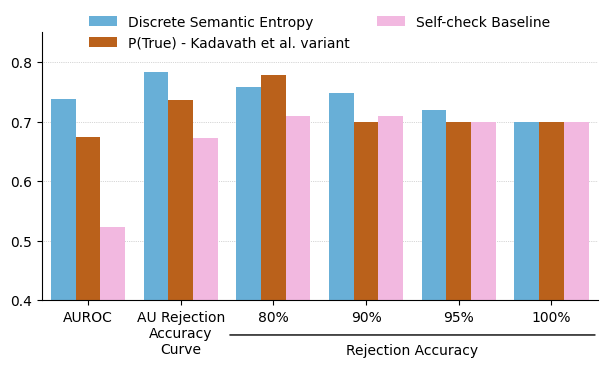

In [454]:
restyled_barplots(include=['FQADebertaEntailment', 'FptrueOrig', 'Fself_check',], save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/paragraph_main.pdf")

True

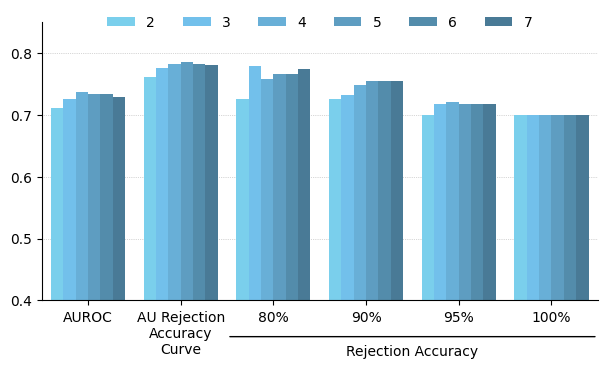

In [447]:
# N_generations ablation for paragraph
restyled_barplots(include=['FQADebertaEntailment-A1', 'FQADebertaEntailment-A2', 'FQADebertaEntailment', 'FQADebertaEntailment-A4', 'FQADebertaEntailment-A5', 'FQADebertaEntailment-A6'], custom_names = [2, 3, 4, 5, 6, 7], ncols=6, save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_paragraph_n_generations_ablation.pdf")

True

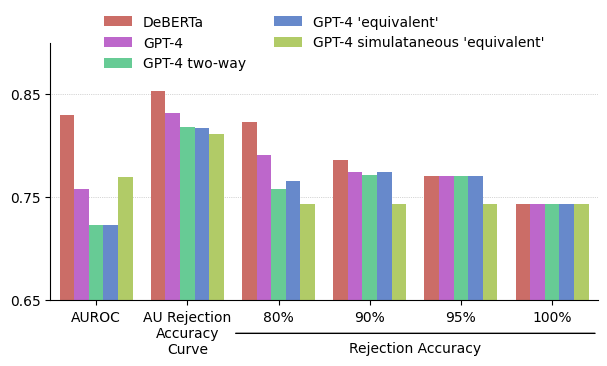

In [379]:
# some other variants from preliminary investigation (dataset half the size)


# LLM equivalence + clustering

# entailment: directly ask LLM if the generated answers are equivalent (all questions at the same time)
# entailment_llm: check entailment with gpt-4
# equivalent_llm: check if answers are 'equivalent' with gpt-4 (simple change of phrasing)
# 1way_entailment_llm: ask closer to how we actually compute (non-strict) entailment: at least one entails the other!
restyled_barplots(
    include=['deberta_not_answerable', '1way_entailment_llm','entailment_llm', 'equivalent_llm', 'entailment'],
    custom_names=['DeBERTa', 'GPT-4', 'GPT-4 two-way', "GPT-4 'equivalent' ", "GPT-4 simulataneous 'equivalent'"],
    y_lims=[0.65,0.9],
    ncols=2,
    save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_paragraph_entailment_ablation.pdf"
)

In [283]:
os.getcwd()

'/auto/users/jansen/long_hallu'

In [313]:
def adjust_color(hex_color, adjustment_factor):
    # Convert hex to RGB
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:], 16)

    # Adjust and ensure within range 0-255
    r = max(min(255, r * adjustment_factor), 0)
    g = max(min(255, g * adjustment_factor), 0)
    b = max(min(255, b * adjustment_factor), 0)

    # Convert back to hex and return
    return f'#{int(r):02x}{int(g):02x}{int(b):02x}'

# Central color
central_color = '#56b4e9'

# Generate two lighter shades
lighter_shades = [adjust_color(central_color, 1.1), adjust_color(central_color, 1.2)]

# Generate three darker shades
darker_shades = [adjust_color(central_color, 0.9), adjust_color(central_color, 0.8), adjust_color(central_color, 0.7)]

# Combine all shades with the central color in the middle
spectrum = darker_shades + [central_color] + lighter_shades

print(spectrum)


['#4da2d1', '#4490ba', '#3c7da3', '#56b4e9', '#5ec6ff', '#67d8ff']


In [372]:
y_lims=[0.65,0.9]


array([0.65, 0.75, 0.85])